In [1]:
!pip install ultralytics opencv-python mediapipe numpy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


Import Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import mediapipe as mp

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Image Loading

Saving images (2).jpg to images (2) (1).jpg


(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

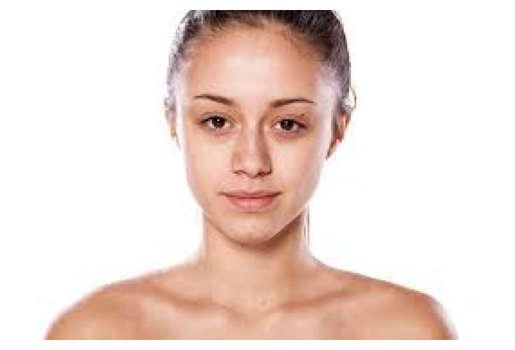

In [80]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [4]:
!pip uninstall mediapipe -y

Found existing installation: mediapipe 0.10.32
Uninstalling mediapipe-0.10.32:
  Successfully uninstalled mediapipe-0.10.32


In [5]:
!pip install mediapipe -q

In [6]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

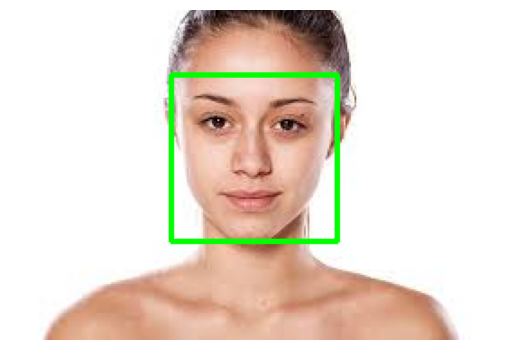

In [81]:
# The original error was: SyntaxError: positional argument follows keyword argument
# This was due to `vision.FaceDetector` being passed as a positional argument after `model_asset_path='image_path'`.
# Also, the usage of MediaPipe FaceDetector was incorrect.

# 1. Download the MediaPipe Face Detector model.
#    This model is required for the FaceDetector to function.
!wget -q -O blaze_face_short_range.tflite https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite

# Define the path to the downloaded model
model_path = 'blaze_face_short_range.tflite'

# 2. Create BaseOptions for the model
base_options = python.BaseOptions(model_asset_path=model_path)

# 3. Create FaceDetectorOptions
options = vision.FaceDetectorOptions(base_options=base_options, min_detection_confidence=0.5)

# 4. Create the FaceDetector
face_detector = vision.FaceDetector.create_from_options(options)

# The 'img' variable is already loaded from 'person.jpg' in a previous cell
# and is already converted to RGB. We will use this existing 'img'.
# For MediaPipe tasks, convert the numpy array to an mp.Image object.
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)

# Perform face detection
detection_result = face_detector.detect(mp_image)

# Draw bounding boxes on the original image
# Make a copy of the image to draw on, so the original 'img' isn't modified for subsequent operations if needed.
display_img = img.copy()

if detection_result.detections:
    for detection in detection_result.detections:
        bbox = detection.bounding_box
        # Use the raw bounding box coordinates directly
        x = bbox.origin_x
        y = bbox.origin_y
        width = bbox.width
        height = bbox.height

        # Draw rectangle on the numpy image copy
        cv2.rectangle(display_img,(x,y),(x+width,y+height),(0,255,0),2)

# Display the image with detections
plt.imshow(display_img)
plt.axis("off")

In [82]:
def detect_acne(image_segment):

    hsv = cv2.cvtColor(image_segment, cv2.COLOR_RGB2HSV)

    lower_red = np.array([0,120,70])
    upper_red = np.array([10,255,255])

    mask = cv2.inRange(hsv, lower_red, upper_red)

    acne_pixels = np.sum(mask>0)

    if acne_pixels < 1000:
        level = " very Low Acne"
    elif acne_pixels < 5000:
        level = "Low Acne"
    elif acne_pixels < 15000:
        level = "Medium Acne"
    elif acne_pixels < 20000:
        level = "High Acne"
    else:
        level= " High Acne"

    return level, acne_pixels

# Prepare the image segment for acne detection
face_to_analyze = None
if detection_result.detections:
    # Get the bounding box of the first detected face
    first_detection = detection_result.detections[0]
    bbox = first_detection.bounding_box

    # Extract coordinates
    x = bbox.origin_x
    y = bbox.origin_y
    width = bbox.width
    height = bbox.height

    # Crop the face from the original image (img)
    # Ensure coordinates are within image bounds
    h_img, w_img, _ = img.shape
    x_end = min(x + width, w_img)
    y_end = min(y + height, h_img)
    x_start = max(0, x)
    y_start = max(0, y)

    if x_end > x_start and y_end > y_start:
        face_to_analyze = img[y_start:y_end, x_start:x_end]
    else:
        print("Invalid face bounding box (perhaps out of image bounds after adjustments), using full image for acne detection.")
        face_to_analyze = img.copy()
else:
    print("No face detected. Analyzing the whole image for acne (may not be accurate).")
    face_to_analyze = img.copy() # Use the whole image if no face is detected

# Perform acne detection on the prepared image segment
if face_to_analyze is not None:
    acne_level, acne_score = detect_acne(face_to_analyze)
    print("Acne Level:", acne_level)
else:
    print("Error: Could not obtain an image segment for acne detection.")

Acne Level:  very Low Acne


In [83]:
def detect_wrinkles(face):

    gray = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)

    edges = cv2.Canny(gray,100,200)

    wrinkle_score = np.sum(edges)

    if wrinkle_score < 100000:
        result = "Low Wrinkles"
    elif wrinkle_score < 500000:
        result = "Moderate Wrinkles"
    elif wrinkle_score < 1000000:
        result = "High Wrinkles"
    else:
        result = "Severe Wrinkles"

    return result, wrinkle_score

# Call detect_wrinkles with the 'face_to_analyze' variable from the previous cell
# which contains the cropped face or the full image.
wrinkle_level, wrinkle_score = detect_wrinkles(face_to_analyze)

print("Wrinkle Level:", wrinkle_level)

Wrinkle Level: Moderate Wrinkles


In [85]:
def detect_dark_circles(face):

    h, w, _ = face.shape

    eye_region = face[int(h*0.45):int(h*0.65), int(w*0.2):int(w*0.8)]

    gray = cv2.cvtColor(eye_region, cv2.COLOR_RGB2GRAY)

    brightness = np.mean(gray)

    if brightness < 150:
        result = "Severe Dark Circles"
    elif brightness < 50:
        result = "Moderate Dark Circles"
    else:
        result = "Healthy Under-Eye"

    return result, brightness

dark_circle_level, eye_score = detect_dark_circles(face_to_analyze)

print("Dark Circles:", dark_circle_level)

Dark Circles: Healthy Under-Eye


In [86]:
def analyze_skin_brightness(face):

    gray = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)

    brightness = np.mean(gray)

    if brightness < 80:
        result = "Dry / Dull Skin"
    elif brightness < 150:
        result = "Normal Skin"
    else:
        result = "Oily / Shiny Skin"

    return brightness, result

brightness, skin_type = analyze_skin_brightness(face_to_analyze)

print("Skin Brightness:", brightness)
print("Skin Condition:", skin_type)

Skin Brightness: 189.60018903591683
Skin Condition: Oily / Shiny Skin


In [87]:
def detect_hair_loss(img):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    edges = cv2.Canny(gray,50,150)

    density = np.sum(edges)/(edges.shape[0]*edges.shape[1])

    if density < 5:
        result = "High Hair Loss"
    elif density < 15:
        result = "Moderate Hair Loss"
    else:
        result = "Healthy Hair"

    return result, density

hair_result, hair_density = detect_hair_loss(img)

print("Hair Condition:", hair_result)

Hair Condition: Moderate Hair Loss


In [76]:
def beauty_recommendation(acne, wrinkle, dark_circle, hair, skin_type):

    recommendations = []

    if "Moderate" in acne or "Severe" in acne:
        recommendations.append("Use Salicylic Acid Cleanser")
        recommendations.append("Acne Treatment Facial")

    if "Moderate" in wrinkle or "High" in wrinkle:
        recommendations.append("Use Retinol Cream")
        recommendations.append("Anti-aging Facial")

    if "Dark" in dark_circle:
        recommendations.append("Vitamin C Eye Cream")
        recommendations.append("Improve Sleep Schedule")

    if "Hair Loss" in hair:
        recommendations.append("Use Biotin Shampoo")
        recommendations.append("Hair Growth Serum")
        recommendations.append("Scalp Therapy")

    if "Dry" in skin_type or "Dull" in skin_type:
        recommendations.append("Use gentle and thick moisturizers")
        recommendations.append("Use Hydrating Cleanser")
        recommendations.append("Avoid Hot Showers")

    if "Oily" in skin_type or "Shiny" in skin_type:
        recommendations.append("Use Matte-finish sunscreen")
        recommendations.append("Use Niacinamide Serum")
        recommendations.append("Using Gel-based cleanser contain Salicylic Acid")

    return recommendations

rec = beauty_recommendation(acne_level, wrinkle_level, dark_circle_level, hair_result,skin_type)

print("------ Personalized Beauty Plan ------")

for r in rec:
    print("-", r)

------ Personalized Beauty Plan ------
- Vitamin C Eye Cream
- Improve Sleep Schedule


In [77]:
print("===== AI BEAUTY PASSPORT REPORT =====")

print("Acne:", acne_level)
print("Wrinkles:", wrinkle_level)
print("Dark Circles:", dark_circle_level)
print("Skin Type:", skin_type)
print("Hair Condition:", hair_result)

print("\nRecommended Treatments:")

for r in rec:
    print("-", r)

===== AI BEAUTY PASSPORT REPORT =====
Acne:  very Low Acne
Wrinkles: Low Wrinkles
Dark Circles: Severe Dark Circles
Skin Type: Normal Skin
Hair Condition: Healthy Hair

Recommended Treatments:
- Vitamin C Eye Cream
- Improve Sleep Schedule


In [78]:
def predictive_homecare(acne, wrinkle, dark_circle, hair, hydration):

    routine = {}

    morning = []
    night = []
    hair_care = []

    # Skin hydration prediction
    if hydration == "Low Hydration":
        morning.append("Hyaluronic Acid Moisturizer")
        night.append("Deep Hydration Cream")

    # Acne prediction
    if "Moderate" in acne or "Severe" in acne:
        morning.append("Salicylic Acid Cleanser")
        night.append("Acne Spot Treatment")

    # Wrinkle prediction
    if "Moderate" in wrinkle or "High" in wrinkle:
        night.append("Retinol Anti-aging Cream")

    # Dark circle prediction
    if "Dark" in dark_circle:
        morning.append("Vitamin C Eye Cream")
        night.append("Under-eye Repair Gel")

    # Hair prediction
    if "Hair Loss" in hair:
        hair_care.append("Biotin Shampoo (3x per week)")
        hair_care.append("Hair Growth Serum")
        hair_care.append("Scalp Massage")

    routine["Morning Routine"] = morning
    routine["Night Routine"] = night
    routine["Hair Care"] = hair_care

    return routine

In [79]:
plan = predictive_homecare(
    acne="Moderate Acne",
    wrinkle="Low Wrinkles",
    dark_circle="Moderate Dark Circles",
    hair="Moderate Hair Loss",
    hydration="Low Hydration"
)

for key, value in plan.items():
    print("\n", key)
    for item in value:
        print("-", item)


 Morning Routine
- Hyaluronic Acid Moisturizer
- Salicylic Acid Cleanser
- Vitamin C Eye Cream

 Night Routine
- Deep Hydration Cream
- Acne Spot Treatment
- Under-eye Repair Gel

 Hair Care
- Biotin Shampoo (3x per week)
- Hair Growth Serum
- Scalp Massage
